# Portfolio Analytics — cartera concentrada

Primera pasada de análisis de **cartera** (no de acción individual, eso ya lo cubren `eda_cedears.ipynb` y las demás). La selección de empresas viene de `seleccionar_cartera.py` — reusamos sus funciones acá directo, no se reescribe el criterio en dos lugares.

**SKHY se trata aparte**: pasa el filtro fundamental (score más alto de todos), pero solo tiene ~60 días de historial de precio — no alcanza para una matriz de covarianza ni una frontera eficiente confiables junto con nombres que tienen 1200+ días. Se muestra su volatilidad/CVaR individual (con la salvedad de la ventana corta), pero queda **fuera** de la correlación y la frontera eficiente.

Todo lo de acá sale de `fact_precios_daily` (5 años de historia) — no hace falta ninguna fuente de datos nueva.

In [1]:
import sys
sys.path.insert(0, "..")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

from seleccionar_cartera import (
    obtener_candidatos, aplicar_filtro_calidad, calcular_ranking,
    marcar_alertas_externas, elegir_diversificado, TAMANIO_CARTERA_DEFAULT, MAX_POR_SECTOR,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

candidatos = obtener_candidatos(con)
filtrados = aplicar_filtro_calidad(candidatos)
rankeados = marcar_alertas_externas(calcular_ranking(filtrados))
cartera = elegir_diversificado(rankeados, TAMANIO_CARTERA_DEFAULT, MAX_POR_SECTOR)

TICKERS = cartera["ticker_usd"].tolist()
TICKERS_HISTORIA_CORTA = cartera[cartera["alerta_historia_corta"]]["ticker_usd"].tolist()
TICKERS_FULL = [t for t in TICKERS if t not in TICKERS_HISTORIA_CORTA]

print(f"Cartera ({len(TICKERS)}): {TICKERS}")
print(f"Con historia corta (se tratan aparte): {TICKERS_HISTORIA_CORTA}")
cartera[["ticker_usd", "nombre_empresa", "sector", "score_compuesto", "dias_precio"]]

Cartera (9): ['SKHY', 'FSLR', 'ALUA', 'TCOM', 'TGNO4', 'PDD', 'GFI', 'YELP', 'CAAP']
Con historia corta (se tratan aparte): ['SKHY']


,ticker_usd,nombre_empresa,sector,score_compuesto,dias_precio
88,SKHY,Sk Hynix Inc,Technology,0.911878,62
244,FSLR,First Solar Inc,Technology,0.866780,1291
246,ALUA,Aluar,Basic Materials,0.866557,1232
165,TCOM,Ctrip.Com International,Consumer Cyclical,0.847043,1291
91,TGNO4,Transportadora Gas Del Norte,Energy,0.839003,1232
44,PDD,Pdd Holdings Inc,Consumer Cyclical,0.834617,1291
326,GFI,Gold Fields Ltd,Basic Materials,0.831693,1291
113,YELP,Yelp Inc,Communication Services,0.818535,1291
43,CAAP,Corporacion America Air,Industrials,0.803915,1291


In [2]:
precios = con.execute(
    "SELECT ticker_usd, fecha, adj_close FROM fact_precios_daily WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL ORDER BY fecha",
    [TICKERS],
).fetchdf()
pivot_todos = precios.pivot(index="fecha", columns="ticker_usd", values="adj_close")

# Para correlacion/frontera: solo los tickers con historia completa, alineados
# (dropna sin 'how=all' -- se exige que TODOS tengan dato esa fecha, para que
# la matriz de covarianza no tenga huecos distintos por columna).
pivot_full = pivot_todos[TICKERS_FULL].dropna()
retornos_full = pivot_full.pct_change().dropna()

print(f"Ventana alineada para correlación/frontera: {len(pivot_full)} días ({pivot_full.index.min().date()} a {pivot_full.index.max().date()})")

Ventana alineada para correlación/frontera: 1198 días (2021-09-28 a 2026-10-06)


## 1. Volatilidad, asimetría y curtosis

Volatilidad anualizada = desvío estándar de retornos diarios × √252. Asimetría negativa = caídas más bruscas que las subas (cola izquierda más pesada). Curtosis alta = más eventos extremos de lo que predice una normal ("fat tails") — relevante para saber si confiar en VaR/CVaR paramétrico o solo en el histórico (acá usamos histórico, así que no depende de asumir normalidad).

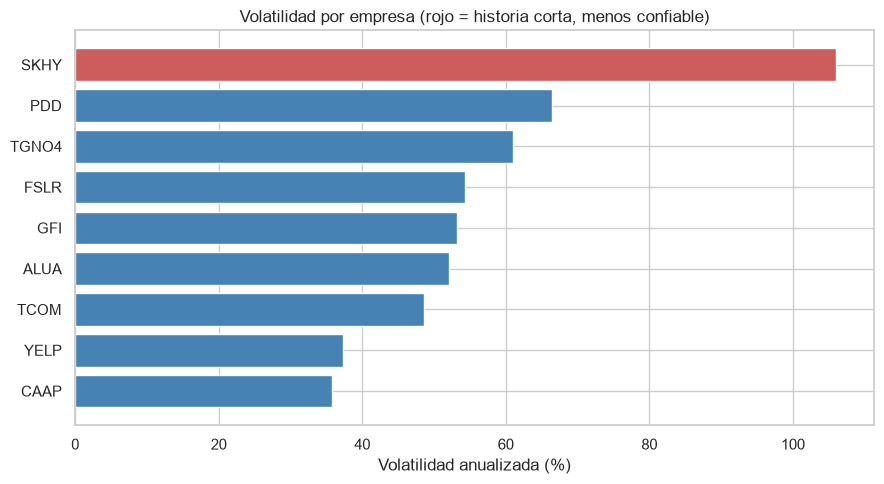

,ticker_usd,nombre_empresa,dias,vol_anual_pct,asimetria,curtosis
0,SKHY,Sk Hynix Inc,61,106.00,1.16,3.46
5,PDD,Pdd Holdings Inc,1290,66.49,1.78,29.48
4,TGNO4,Transportadora Gas Del Norte,1231,61.03,1.67,14.28
1,FSLR,First Solar Inc,1290,54.33,0.87,6.69
6,GFI,Gold Fields Ltd,1290,53.18,-0.30,3.96
2,ALUA,Aluar,1231,52.12,-0.00,2.79
3,TCOM,Ctrip.Com International,1290,48.58,0.33,8.63
7,YELP,Yelp Inc,1290,37.34,-0.04,7.19
8,CAAP,Corporacion America Air,1290,35.72,0.81,5.18


In [3]:
filas = []
for t in TICKERS:
    r = pivot_todos[t].dropna().pct_change().dropna()
    filas.append({
        "ticker_usd": t,
        "dias": len(r),
        "vol_anual_pct": r.std() * np.sqrt(252) * 100,
        "asimetria": stats.skew(r),
        "curtosis": stats.kurtosis(r),
    })
stats_df = pd.DataFrame(filas).merge(cartera[["ticker_usd", "nombre_empresa"]], on="ticker_usd").sort_values("vol_anual_pct", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["indianred" if t in TICKERS_HISTORIA_CORTA else "steelblue" for t in stats_df["ticker_usd"]]
ax.barh(stats_df["ticker_usd"], stats_df["vol_anual_pct"], color=colors)
ax.set_xlabel("Volatilidad anualizada (%)")
ax.set_title("Volatilidad por empresa (rojo = historia corta, menos confiable)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

stats_df[["ticker_usd", "nombre_empresa", "dias", "vol_anual_pct", "asimetria", "curtosis"]].round(2)

## 2. Correlación

Solo los tickers con historia completa (ver arriba). Ojo acá: la diversificación por SECTOR (lo que ya hace `seleccionar_cartera.py`) no garantiza baja correlación — países/regiones comparten macro aunque el sector GICS sea distinto.

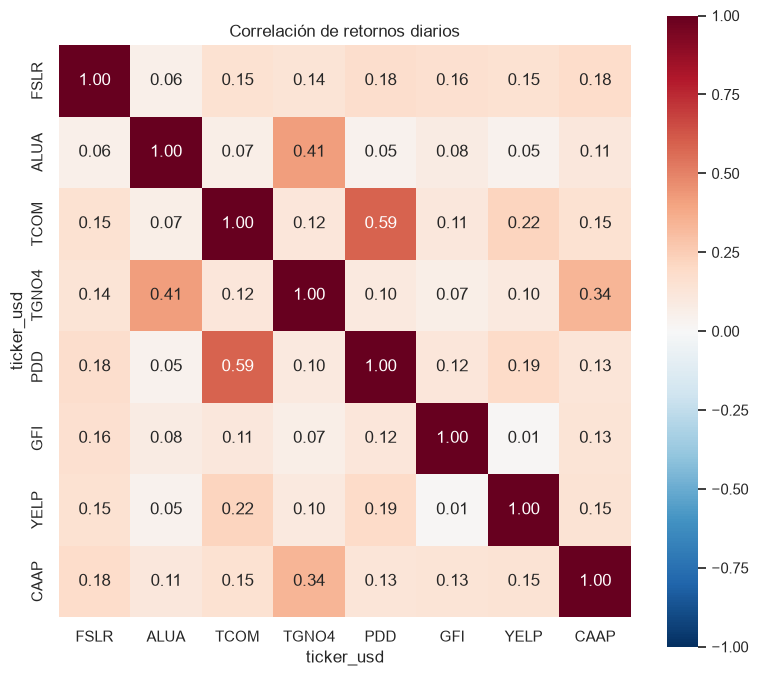

Pares más correlacionados:
ticker_usd  ticker_usd
TCOM        PDD           0.588714
ALUA        TGNO4         0.414100
TGNO4       CAAP          0.336642
TCOM        YELP          0.223236
PDD         YELP          0.189219

Pares menos correlacionados (mejores diversificadores entre sí):
ticker_usd  ticker_usd
TGNO4       GFI           0.070038
FSLR        ALUA          0.060190
ALUA        PDD           0.045671
            YELP          0.045134
GFI         YELP          0.012148


In [4]:
corr = retornos_full.corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Correlación de retornos diarios")
plt.tight_layout()
plt.show()

# Pares mas correlacionados (fuera de la diagonal)
pares = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().dropna().sort_values(ascending=False)
print("Pares más correlacionados:")
print(pares.head(5).to_string())
print("\nPares menos correlacionados (mejores diversificadores entre sí):")
print(pares.tail(5).to_string())

## 3. Drawdowns

Caída máxima desde el pico previo, y cuántos días tardó en recuperar ese nivel (vacío = todavía no recuperó).

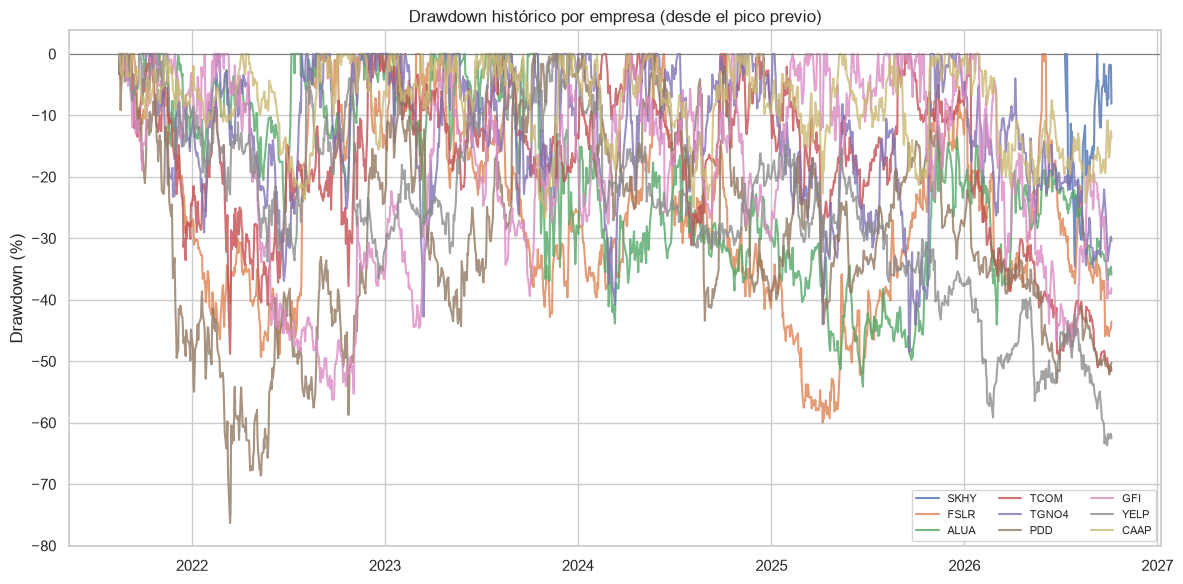

,ticker_usd,max_drawdown_pct,fecha_minimo,dias_recuperacion,nombre_empresa
5,PDD,-76.304064,2022-03-14,575.0,Pdd Holdings Inc
7,YELP,-63.679537,2026-09-28,NaN,Yelp Inc
1,FSLR,-59.968075,2025-04-08,415.0,First Solar Inc
6,GFI,-56.223646,2022-09-23,221.0,Gold Fields Ltd
2,ALUA,-54.132598,2025-06-23,NaN,Aluar
3,TCOM,-51.760384,2026-10-02,NaN,Ctrip.Com International
4,TGNO4,-48.513554,2025-09-19,40.0,Transportadora Gas Del Norte
0,SKHY,-34.617367,2026-07-29,42.0,Sk Hynix Inc
8,CAAP,-26.634549,2023-10-31,27.0,Corporacion America Air


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
filas_dd = []
for t in TICKERS:
    precio = pivot_todos[t].dropna()
    cummax = precio.cummax()
    dd = precio / cummax - 1
    ax.plot(dd.index, dd * 100, label=t, alpha=0.8)

    max_dd = dd.min()
    fecha_trough = dd.idxmin()
    pico_previo = precio[:fecha_trough].max()
    despues = precio[fecha_trough:]
    recuperado = despues[despues >= pico_previo]
    dias_recuperacion = (recuperado.index[0] - fecha_trough).days if len(recuperado) else None
    filas_dd.append({
        "ticker_usd": t, "max_drawdown_pct": max_dd * 100,
        "fecha_minimo": fecha_trough.date(), "dias_recuperacion": dias_recuperacion,
    })

ax.axhline(0, color="grey", linewidth=0.8)
ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown histórico por empresa (desde el pico previo)")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

pd.DataFrame(filas_dd).merge(cartera[["ticker_usd", "nombre_empresa"]], on="ticker_usd").sort_values("max_drawdown_pct")

## 4. CVaR histórico (95%)

VaR 95% = la pérdida diaria que no se supera el 95% de las veces (percentil 5 de los retornos). CVaR 95% = el promedio de los días que SÍ superan esa pérdida — "si tenés un mal día, en promedio cuánto perdés". Histórico, no paramétrico (no asume retornos normales — importante dado que varias de estas empresas tienen curtosis alta, colas más pesadas que una normal).

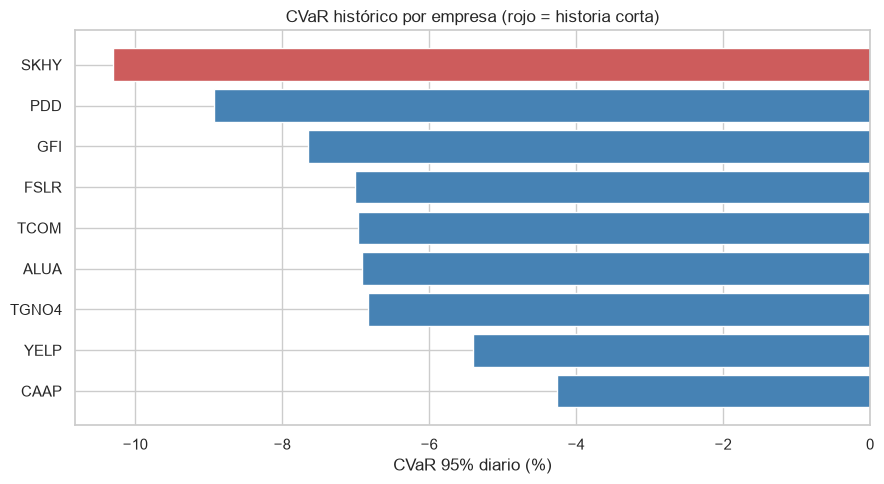

,ticker_usd,VaR_95_pct,CVaR_95_pct,nombre_empresa
0,SKHY,-9.00,-10.30,Sk Hynix Inc
5,PDD,-5.76,-8.93,Pdd Holdings Inc
6,GFI,-4.87,-7.65,Gold Fields Ltd
1,FSLR,-4.72,-7.01,First Solar Inc
3,TCOM,-4.23,-6.96,Ctrip.Com International
2,ALUA,-4.87,-6.91,Aluar
4,TGNO4,-5.05,-6.83,Transportadora Gas Del Norte
7,YELP,-3.58,-5.40,Yelp Inc
8,CAAP,-3.05,-4.26,Corporacion America Air


In [6]:
filas_cvar = []
for t in TICKERS:
    r = pivot_todos[t].dropna().pct_change().dropna()
    var95 = r.quantile(0.05)
    cvar95 = r[r <= var95].mean()
    filas_cvar.append({"ticker_usd": t, "VaR_95_pct": var95 * 100, "CVaR_95_pct": cvar95 * 100})

cvar_df = pd.DataFrame(filas_cvar).merge(cartera[["ticker_usd", "nombre_empresa"]], on="ticker_usd").sort_values("CVaR_95_pct")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["indianred" if t in TICKERS_HISTORIA_CORTA else "steelblue" for t in cvar_df["ticker_usd"]]
ax.barh(cvar_df["ticker_usd"], cvar_df["CVaR_95_pct"], color=colors)
ax.set_xlabel("CVaR 95% diario (%)")
ax.set_title("CVaR histórico por empresa (rojo = historia corta)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

cvar_df.round(2)

## 5. Frontera eficiente (Markowitz, sin posiciones cortas)

Sobre los tickers con historia completa. Retorno esperado = promedio histórico anualizado (supuesto fuerte: asume que el pasado se repite — es el punto de partida estándar, no una predicción). Cada punto gris es una empresa sola (100% en esa posición); la curva azul es la frontera eficiente; el punto verde es la cartera de mínima varianza; el punto naranja es la cartera equal-weight (la selección "cruda", sin optimizar pesos).

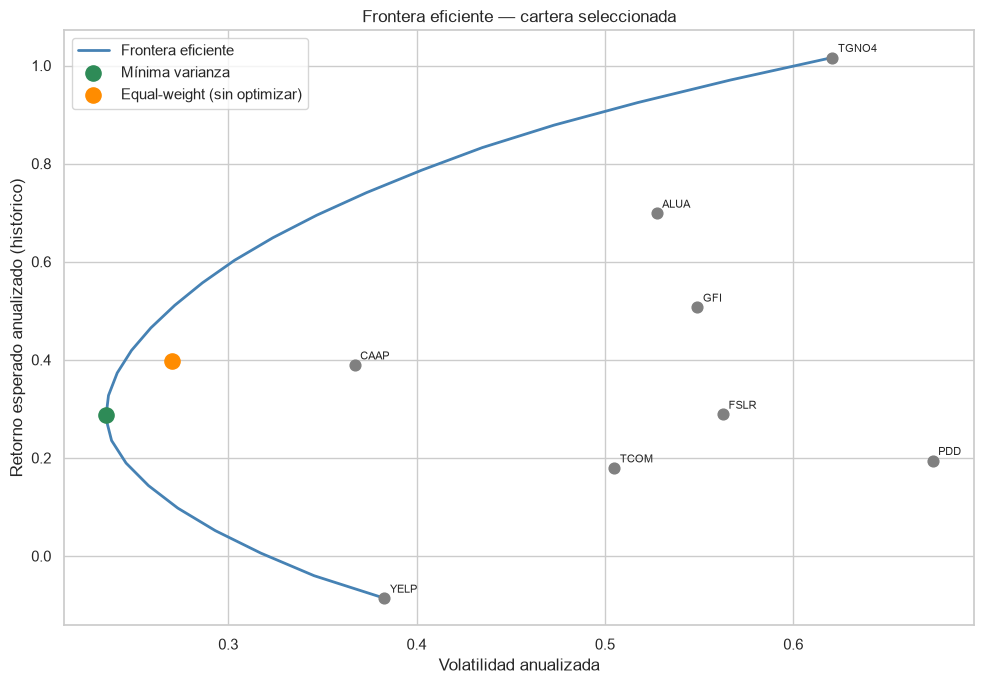

Cartera de mínima varianza:
YELP     28.1
CAAP     27.8
ALUA     14.7
GFI      12.3
TCOM     10.0
FSLR      7.1
TGNO4     0.0
PDD       0.0

Retorno esperado: 28.8% | Volatilidad: 23.5%

Equal-weight -> Retorno esperado: 39.9% | Volatilidad: 27.0%


In [7]:
mu = retornos_full.mean() * 252
cov = retornos_full.cov() * 252
n = len(TICKERS_FULL)

def vol_cartera(w):
    return np.sqrt(w @ cov.values @ w)

def retorno_cartera(w):
    return w @ mu.values

bounds = [(0, 1)] * n
restriccion_suma = {"type": "eq", "fun": lambda w: np.sum(w) - 1}

# Cartera de minima varianza
res_minvar = minimize(vol_cartera, x0=np.ones(n) / n, bounds=bounds, constraints=[restriccion_suma])

# Frontera: minima vol para cada retorno objetivo entre el minimo y el maximo individual
objetivos = np.linspace(mu.min(), mu.max(), 25)
frontera = []
for obj in objetivos:
    cons = [restriccion_suma, {"type": "eq", "fun": lambda w, obj=obj: retorno_cartera(w) - obj}]
    res = minimize(vol_cartera, x0=np.ones(n) / n, bounds=bounds, constraints=cons)
    if res.success:
        frontera.append((vol_cartera(res.x), obj))
frontera_df = pd.DataFrame(frontera, columns=["vol", "retorno"])

w_equal = np.ones(n) / n

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(np.sqrt(np.diag(cov)), mu, color="grey", s=60, zorder=3)
for t in TICKERS_FULL:
    ax.annotate(t, (np.sqrt(cov.loc[t, t]), mu[t]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.plot(frontera_df["vol"], frontera_df["retorno"], color="steelblue", linewidth=2, label="Frontera eficiente")
ax.scatter([vol_cartera(res_minvar.x)], [retorno_cartera(res_minvar.x)], color="seagreen", s=120, zorder=4, label="Mínima varianza")
ax.scatter([vol_cartera(w_equal)], [retorno_cartera(w_equal)], color="darkorange", s=120, zorder=4, label="Equal-weight (sin optimizar)")
ax.set_xlabel("Volatilidad anualizada")
ax.set_ylabel("Retorno esperado anualizado (histórico)")
ax.set_title("Frontera eficiente — cartera seleccionada")
ax.legend()
plt.tight_layout()
plt.show()

print("Cartera de mínima varianza:")
pesos_minvar = pd.Series(res_minvar.x, index=TICKERS_FULL).sort_values(ascending=False)
print((pesos_minvar * 100).round(1).to_string())
print(f"\nRetorno esperado: {retorno_cartera(res_minvar.x):.1%} | Volatilidad: {vol_cartera(res_minvar.x):.1%}")
print(f"\nEqual-weight -> Retorno esperado: {retorno_cartera(w_equal):.1%} | Volatilidad: {vol_cartera(w_equal):.1%}")

## 6. Simulación: ¿dónde puede terminar la cartera en un año?

Bootstrap por bloques sobre los retornos diarios de la cartera equal-weight (rebalanceada a diario): se arman miles de "años posibles" pegando bloques de 21 días hábiles consecutivos tomados al azar de la historia. Se sortean bloques y no días sueltos para conservar las rachas — varios días malos seguidos son justo el riesgo que interesa, y sortear días sueltos las borraría.

No es machine learning ni una predicción: es re-ordenar lo que ya pasó. Por eso hereda el sesgo de la muestra — estos 5 años fueron muy buenos para estas acciones (y las elegimos mirando datos de hoy), así que el escenario **histórico** es optimista. Se muestra al lado un escenario **conservador**: mismos riesgos (misma volatilidad, mismas rachas), pero con el retorno promedio reemplazado por `RETORNO_CONSERVADOR_ANUAL`. La lectura útil está en la dispersión y en la cola mala, no en la mediana. (En el conservador la mediana queda por debajo del objetivo: con esta volatilidad, el resultado típico es menor que el promedio — unos pocos escenarios muy buenos suben la media.)

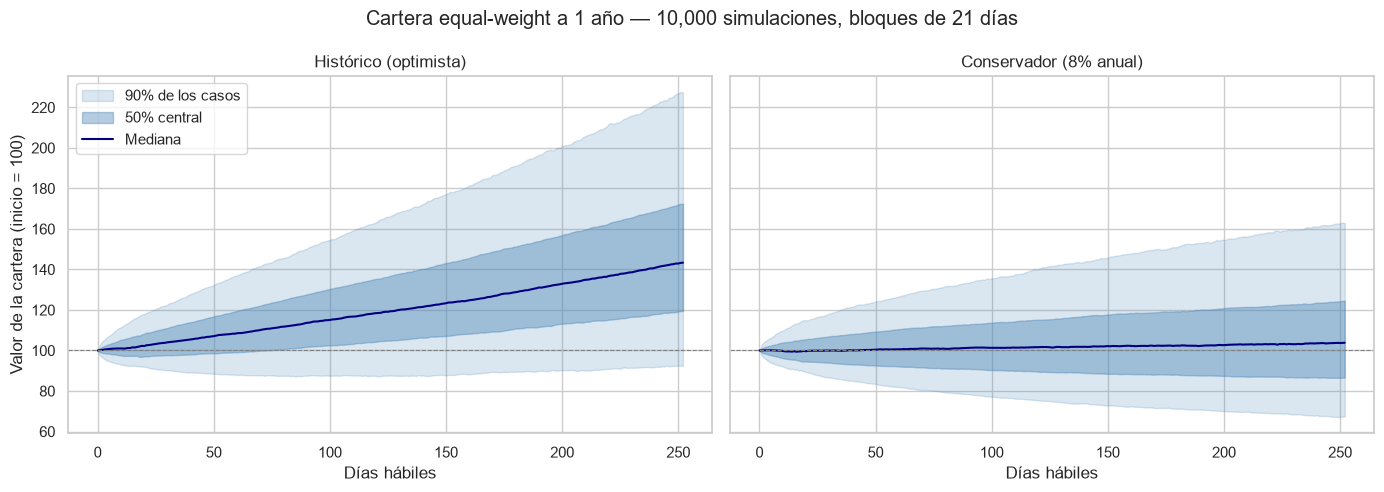

Retorno histórico anualizado de la cartera: 49% | volatilidad: 27%


,Histórico (optimista),Conservador (8% anual)
retorno mediano %,43.3,3.8
peor 5% (percentil 5) %,-7.6,-32.6
CVaR 95% a 1 año %,-16.0,-38.8
mejor 5% (percentil 95) %,127.3,62.9
prob. de terminar en pérdida %,9.0,44.8
caída máxima mediana %,-17.7,-24.8
caída máxima en el peor 5% %,-30.4,-42.1


In [8]:
RETORNO_CONSERVADOR_ANUAL = 0.08
BLOQUE_DIAS = 21
N_SIMS = 10_000
rng = np.random.default_rng(42)

ret_cartera = (retornos_full @ w_equal).to_numpy()
ret_conservador = ret_cartera - ret_cartera.mean() + ((1 + RETORNO_CONSERVADOR_ANUAL) ** (1 / 252) - 1)


def bootstrap_bloques(r: np.ndarray, horizonte: int, n_sims: int = N_SIMS, bloque: int = BLOQUE_DIAS) -> np.ndarray:
    """Matriz (n_sims, horizonte) de retornos diarios, armada con bloques consecutivos (circular)."""
    n_bloques = int(np.ceil(horizonte / bloque))
    inicios = rng.integers(0, len(r), size=(n_sims, n_bloques))
    idx = (inicios[:, :, None] + np.arange(bloque)[None, None, :]) % len(r)
    return r[idx.reshape(n_sims, -1)[:, :horizonte]]


def trayectorias(r_sim: np.ndarray) -> np.ndarray:
    return np.concatenate([np.ones((len(r_sim), 1)), np.cumprod(1 + r_sim, axis=1)], axis=1)


def resumen_sim(tray: np.ndarray) -> dict:
    final = tray[:, -1] - 1
    max_dd = (tray / np.maximum.accumulate(tray, axis=1) - 1).min(axis=1)
    p5 = np.quantile(final, 0.05)
    return {
        "retorno mediano %": np.median(final) * 100,
        "peor 5% (percentil 5) %": p5 * 100,
        "CVaR 95% a 1 año %": final[final <= p5].mean() * 100,
        "mejor 5% (percentil 95) %": np.quantile(final, 0.95) * 100,
        "prob. de terminar en pérdida %": (final < 0).mean() * 100,
        "caída máxima mediana %": np.median(max_dd) * 100,
        "caída máxima en el peor 5% %": np.quantile(max_dd, 0.05) * 100,
    }


escenarios = {"Histórico (optimista)": ret_cartera, f"Conservador ({RETORNO_CONSERVADOR_ANUAL:.0%} anual)": ret_conservador}
tray_1a = {nombre: trayectorias(bootstrap_bloques(r, 252)) for nombre, r in escenarios.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (nombre, tray) in zip(axes, tray_1a.items()):
    p = np.quantile(tray, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0) * 100
    dias = np.arange(tray.shape[1])
    ax.fill_between(dias, p[0], p[4], color="steelblue", alpha=0.2, label="90% de los casos")
    ax.fill_between(dias, p[1], p[3], color="steelblue", alpha=0.4, label="50% central")
    ax.plot(dias, p[2], color="navy", label="Mediana")
    ax.axhline(100, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(nombre)
    ax.set_xlabel("Días hábiles")
axes[0].set_ylabel("Valor de la cartera (inicio = 100)")
axes[0].legend(loc="upper left")
plt.suptitle(f"Cartera equal-weight a 1 año — {N_SIMS:,} simulaciones, bloques de {BLOQUE_DIAS} días")
plt.tight_layout()
plt.show()

print(f"Retorno histórico anualizado de la cartera: {(1 + ret_cartera.mean()) ** 252 - 1:.0%} | volatilidad: {ret_cartera.std() * np.sqrt(252):.0%}")
pd.DataFrame({nombre: resumen_sim(tray) for nombre, tray in tray_1a.items()}).round(1)

## 7. Regímenes de mercado (VIX)

El VIX mide la volatilidad que el mercado espera para el S&P 500 — sirve como termómetro de miedo. Se parte la historia en tres regímenes con umbrales fijos (`VIX_CALMA`, `VIX_ESTRES`; convención habitual, no optimizados) y se recalcula todo en cada uno.

La pregunta de fondo: **¿la diversificación sigue funcionando cuando hace falta?** Si la correlación promedio entre las acciones sube en estrés, la cartera diversifica menos justo cuando más se la necesita, y la volatilidad de la sección 1 subestima el riesgo real en una crisis.

Es descriptivo (qué pasó en cada régimen), no predictivo: no dice cuándo viene el próximo.

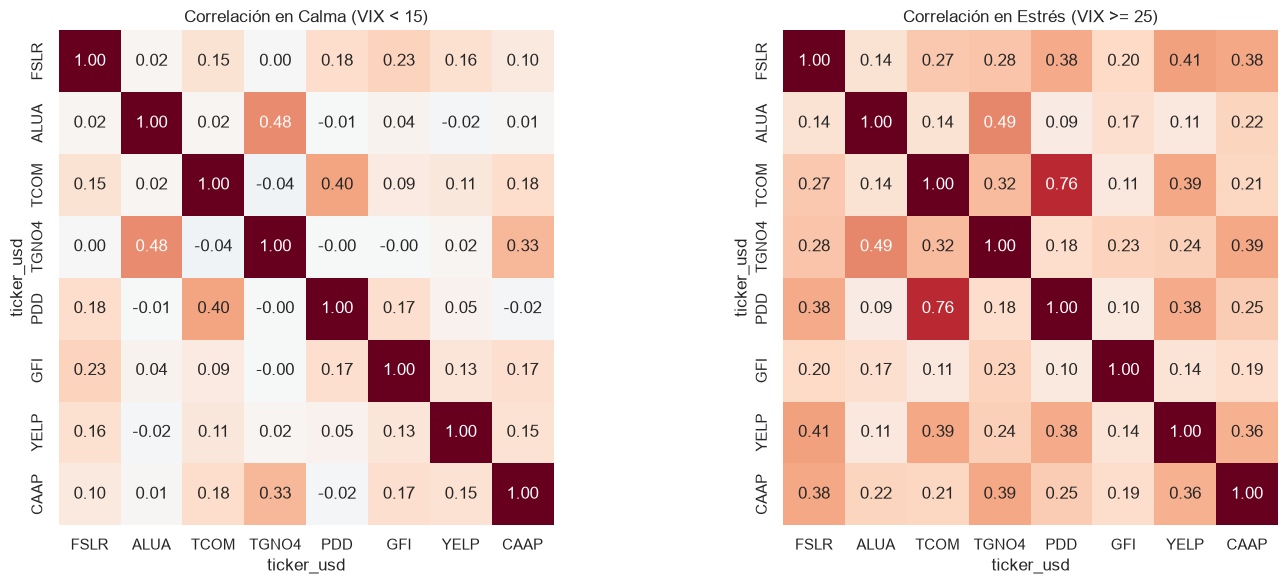

,días,% del período,retorno diario medio %,vol. anualizada %,CVaR 95% diario %,peor día %,correlación promedio entre acciones
régimen,,,,,,,
Calma,262,21.89,0.31,23.52,-2.54,-5.27,0.11
Normal,767,64.08,0.18,24.27,-2.93,-4.57,0.13
Estrés,168,14.04,-0.15,40.40,-5.52,-6.97,0.27


In [9]:
VIX_CALMA, VIX_ESTRES = 15, 25

vix = con.execute("SELECT fecha, valor FROM fact_macro_daily WHERE serie = 'VIX' ORDER BY fecha").fetchdf().set_index("fecha")["valor"]
vix.index = pd.to_datetime(vix.index)
vix_alineado = vix.reindex(pd.to_datetime(retornos_full.index), method="ffill")
regimen = pd.cut(vix_alineado, [0, VIX_CALMA, VIX_ESTRES, np.inf], labels=["Calma", "Normal", "Estrés"], right=False)
regimen.index = retornos_full.index

ret_cartera_s = pd.Series(ret_cartera, index=retornos_full.index)


def corr_promedio(r: pd.DataFrame) -> float:
    c = r.corr().to_numpy()
    return c[np.triu_indices_from(c, k=1)].mean()


filas_reg = []
for nombre in ["Calma", "Normal", "Estrés"]:
    mask = (regimen == nombre).to_numpy()
    r = ret_cartera_s[mask]
    var95 = r.quantile(0.05)
    filas_reg.append({
        "régimen": nombre, "días": int(mask.sum()), "% del período": mask.mean() * 100,
        "retorno diario medio %": r.mean() * 100,
        "vol. anualizada %": r.std() * np.sqrt(252) * 100,
        "CVaR 95% diario %": r[r <= var95].mean() * 100,
        "peor día %": r.min() * 100,
        "correlación promedio entre acciones": corr_promedio(retornos_full[mask]),
    })
regimenes_df = pd.DataFrame(filas_reg).set_index("régimen")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, nombre in zip(axes, ["Calma", "Estrés"]):
    sns.heatmap(retornos_full[(regimen == nombre).to_numpy()].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, ax=ax, square=True, cbar=False)
    ax.set_title(f"Correlación en {nombre} (VIX {'< ' + str(VIX_CALMA) if nombre == 'Calma' else '>= ' + str(VIX_ESTRES)})")
plt.tight_layout()
plt.show()

regimenes_df.round(2)

## 8. Riesgo de secuencia de retornos

Si no se pone ni se saca plata, el orden de los retornos no importa: el resultado final es el mismo. Apenas hay **aportes o retiros**, importa — y mucho:

- Con **retiros**, una caída al principio obliga a vender barato y ese capital ya no está para la recuperación.
- Con **aportes**, es al revés: una caída al principio deja comprar barato; la que duele es la del final, cuando ya está todo el capital adentro.

Dos formas de verlo: (a) la historia real de la cartera contra esa misma historia en orden inverso, y (b) sobre simulaciones a 5 años del escenario conservador, cuánto pesa el primer año contra el último en el resultado final.

(a) Historia real de la cartera (1197 días), capital inicial 100:


,Sin flujos,Aporta 0.5/mes,Retira 0.5/mes
Orden real,558.0,621.1,494.9
Orden invertido,558.0,665.9,450.2


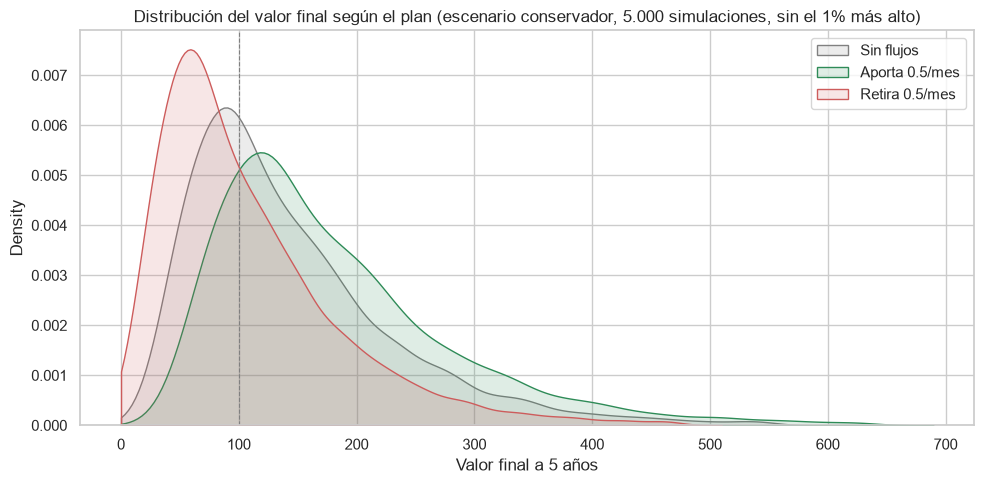

(b) Simulaciones a 5 años, escenario conservador:


,valor final mediano,peor 5%,mediano si el 1er año fue de los peores (tercil bajo),mediano si el último año fue de los peores (tercil bajo),correlación con retorno del 1er año,correlación con retorno del último año
plan,,,,,,
Sin flujos,122.29,44.83,92.38,92.99,0.39,0.42
Aporta 0.5/mes,155.92,65.81,125.78,119.39,0.36,0.45
Retira 0.5/mes,87.56,22.77,58.79,66.39,0.43,0.37


In [10]:
CAPITAL_INICIAL = 100.0
FLUJO_MENSUAL = 0.5  # 0.5% del capital inicial por mes (~6% anual) (cada 21 dias habiles), como aporte o como retiro


def valor_final(r_sim: np.ndarray, flujo_mensual: float) -> np.ndarray:
    """Valor final de cada fila de r_sim (n_sims, dias) con un flujo cada 21 dias. No baja de cero."""
    v = np.full(len(r_sim), CAPITAL_INICIAL)
    for d in range(r_sim.shape[1]):
        v = v * (1 + r_sim[:, d])
        if (d + 1) % 21 == 0:
            v = np.maximum(v + flujo_mensual, 0)
    return v


planes = {"Sin flujos": 0.0, f"Aporta {FLUJO_MENSUAL:g}/mes": FLUJO_MENSUAL, f"Retira {FLUJO_MENSUAL:g}/mes": -FLUJO_MENSUAL}

# (a) mismos retornos, orden real vs. invertido
ordenes = {"Orden real": ret_cartera[None, :], "Orden invertido": ret_cartera[::-1][None, :]}
tabla_orden = pd.DataFrame({plan: {o: valor_final(r, f)[0] for o, r in ordenes.items()} for plan, f in planes.items()})
print(f"(a) Historia real de la cartera ({len(ret_cartera)} días), capital inicial {CAPITAL_INICIAL:g}:")
display(tabla_orden.round(1))

# (b) simulaciones a 5 años, escenario conservador
sim_5a = bootstrap_bloques(ret_conservador, 1260, n_sims=5_000)
ret_primer_anio = np.prod(1 + sim_5a[:, :252], axis=1) - 1
ret_ultimo_anio = np.prod(1 + sim_5a[:, -252:], axis=1) - 1

filas_seq = []
finales = {}
for plan, f in planes.items():
    final = valor_final(sim_5a, f)
    finales[plan] = final
    filas_seq.append({
        "plan": plan,
        "valor final mediano": np.median(final),
        "peor 5%": np.quantile(final, 0.05),
        "mediano si el 1er año fue de los peores (tercil bajo)": np.median(final[ret_primer_anio <= np.quantile(ret_primer_anio, 1 / 3)]),
        "mediano si el último año fue de los peores (tercil bajo)": np.median(final[ret_ultimo_anio <= np.quantile(ret_ultimo_anio, 1 / 3)]),
        "correlación con retorno del 1er año": np.corrcoef(final, ret_primer_anio)[0, 1],
        "correlación con retorno del último año": np.corrcoef(final, ret_ultimo_anio)[0, 1],
    })

fig, ax = plt.subplots(figsize=(10, 5))
for plan, color in zip(planes, ["grey", "seagreen", "indianred"]):
    sns.kdeplot(finales[plan][finales[plan] <= np.quantile(finales[plan], 0.99)], ax=ax, clip=(0, None), label=plan, color=color, fill=True, alpha=0.15)
ax.axvline(CAPITAL_INICIAL, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Valor final a 5 años")
ax.set_title("Distribución del valor final según el plan (escenario conservador, 5.000 simulaciones, sin el 1% más alto)")
ax.legend()
plt.tight_layout()
plt.show()

print("(b) Simulaciones a 5 años, escenario conservador:")
pd.DataFrame(filas_seq).set_index("plan").round(2)

## Límites de todo lo anterior

- Las simulaciones (secciones 6 y 8) solo pueden re-ordenar lo que pasó entre 2021 y 2026. Un tipo de crisis que no está en esa ventana no aparece en ningún escenario: las colas malas están subestimadas.
- Hay sesgo de selección: la cartera se eligió con datos de hoy, y se la simula sobre un pasado en el que a esas empresas ya les fue bien. Por eso el escenario conservador es el que hay que mirar.
- Los pesos son equal-weight con rebalanceo diario, sin costos de transacción ni impuestos.
- Las acciones con historia corta (ver arriba) quedan fuera de estas tres secciones.

Siguiente paso posible: detectar los regímenes con un modelo (Hidden Markov) en vez de umbrales fijos de VIX — eso sí es machine learning y encaja mejor en un proyecto aparte.